# Vision-Based Surface Roughness Estimation Using Texture Feature Extraction on KITTI Dataset

**Course Project — Data Science**

---

## Problem Statement

Road surface roughness affects vehicle stability, passenger comfort, suspension wear, and fuel efficiency. Traditional roughness measurement uses vibration sensors *after* the vehicle drives over a surface — but what if we could **predict** roughness from the camera feed *before* the car gets there?

In this project we build a simple computer vision pipeline that:

1. Takes road images from the **KITTI dataset**
2. Crops out the road region (Region of Interest — ROI)
3. Extracts **texture features** using GLCM and Gabor filters
4. Trains a classifier to label the road as **Smooth / Moderate / Rough**

## Pipeline Overview

```
KITTI Image  →  Preprocessing  →  ROI Extraction  →  Texture Features  →  ML Model  →  Roughness Class
```


## 1. Setup and Imports

We'll use standard computer vision + ML libraries: OpenCV for image processing, scikit-image for GLCM, scikit-learn for the ML models.

If any library is missing, uncomment the pip install line below.

In [1]:
# !pip install numpy pandas opencv-python scikit-image scikit-learn scipy matplotlib tqdm

import os
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis, entropy

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries imported successfully")

All libraries imported successfully


## 2. Configuration

All tunable parameters in one place — makes it easy to experiment without hunting through the notebook.

In [2]:
import os
import cv2

BASE_DIR ='C:\\Users\\Venya Singh\\OneDrive\\Desktop\\data_science_project'
for cam in ['image_00', 'image_01', 'image_02', 'image_03']:
    img_dir = os.path.join(BASE_DIR, cam, 'data')
    
    print("Reading from:", img_dir)
    
    if not os.path.exists(img_dir):
        print("❌ Path not found:", img_dir)
        continue
    
    for file in sorted(os.listdir(img_dir)):
        img_path = os.path.join(img_dir, file)
        img = cv2.imread(img_path)

        if img is None:
            print("Failed:", img_path)
# ----- Preprocessing -----
GAUSSIAN_KSIZE = (5, 5)

# Trapezoidal ROI (as fractions of image h/w)
# KITTI frames are ~1242x375, road sits in the lower-center
ROI_TOP_Y = 0.60          # top edge of trapezoid (60% down from top)
ROI_BOTTOM_Y = 0.95       # bottom edge
ROI_TOP_WIDTH = 0.20      # narrow top
ROI_BOTTOM_WIDTH = 0.70   # wide bottom

# ----- GLCM -----
GLCM_DISTANCES = [1, 2, 3]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]   # 0, 45, 90, 135 deg
GLCM_LEVELS = 32
GLCM_PROPS = ['contrast', 'correlation', 'energy', 'homogeneity', 'dissimilarity']

# ----- Gabor -----
GABOR_WAVELENGTHS = [4.0, 8.0, 16.0]
GABOR_ORIENTATIONS = [0, 45, 90, 135]     # degrees
GABOR_SIGMA = 2.0
GABOR_GAMMA = 0.5

# ----- Classes -----
CLASSES = ['Smooth', 'Moderate', 'Rough']

Reading from: C:\Users\Venya Singh\OneDrive\Desktop\data_science_project\image_00\data
Reading from: C:\Users\Venya Singh\OneDrive\Desktop\data_science_project\image_01\data
Reading from: C:\Users\Venya Singh\OneDrive\Desktop\data_science_project\image_02\data
Reading from: C:\Users\Venya Singh\OneDrive\Desktop\data_science_project\image_03\data


## 3. Preprocessing & ROI Extraction

Before we extract texture features, we need to clean up the image and isolate just the road surface.

**Steps:**
1. **Grayscale conversion** — texture analysis works on intensity, not color
2. **Gaussian blur** — removes small sensor noise
3. **CLAHE (Contrast Limited Adaptive Histogram Equalization)** — normalizes brightness across the image (handles shadows, overexposed sky, etc.)
4. **Trapezoidal ROI mask** — keeps only the drivable road surface and throws out sky, cars, buildings

The trapezoid is narrow at the top (far away, small in image) and wide at the bottom (close to the car). This matches the perspective geometry of a camera mounted on a vehicle.

In [3]:
def get_trapezoid(h, w):
    """Build trapezoid vertices for the road ROI."""
    top_y = int(h * ROI_TOP_Y)
    bot_y = int(h * ROI_BOTTOM_Y)
    top_half = int(w * ROI_TOP_WIDTH) // 2
    bot_half = int(w * ROI_BOTTOM_WIDTH) // 2
    cx = w // 2

    return np.array([
        [cx - bot_half, bot_y],   # bottom-left
        [cx - top_half, top_y],   # top-left
        [cx + top_half, top_y],   # top-right
        [cx + bot_half, bot_y],   # bottom-right
    ], dtype=np.int32)


def preprocess(img_bgr):
    """Full preprocessing: grayscale -> blur -> CLAHE -> ROI crop."""
    # 1. Grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. Gaussian smoothing
    gray = cv2.GaussianBlur(gray, GAUSSIAN_KSIZE, 1.0)

    # 3. CLAHE for histogram normalization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # 4. Apply trapezoidal mask
    h, w = gray.shape
    verts = get_trapezoid(h, w)
    mask = np.zeros_like(gray)
    cv2.fillPoly(mask, [verts], 255)
    masked = cv2.bitwise_and(gray, mask)

    # Crop to bounding box of trapezoid
    x, y, rw, rh = cv2.boundingRect(verts)
    roi = masked[y:y+rh, x:x+rw]
    roi_mask = mask[y:y+rh, x:x+rw] > 0

    return roi, roi_mask


print("Preprocessing functions defined")

Preprocessing functions defined


### Visualize the preprocessing steps

Let's make sure the ROI extraction actually looks right. We'll pick one image and show each step.

Using sample: C:\Users\Venya Singh\OneDrive\Desktop\data_science_project\image_00\data\0000000000.png


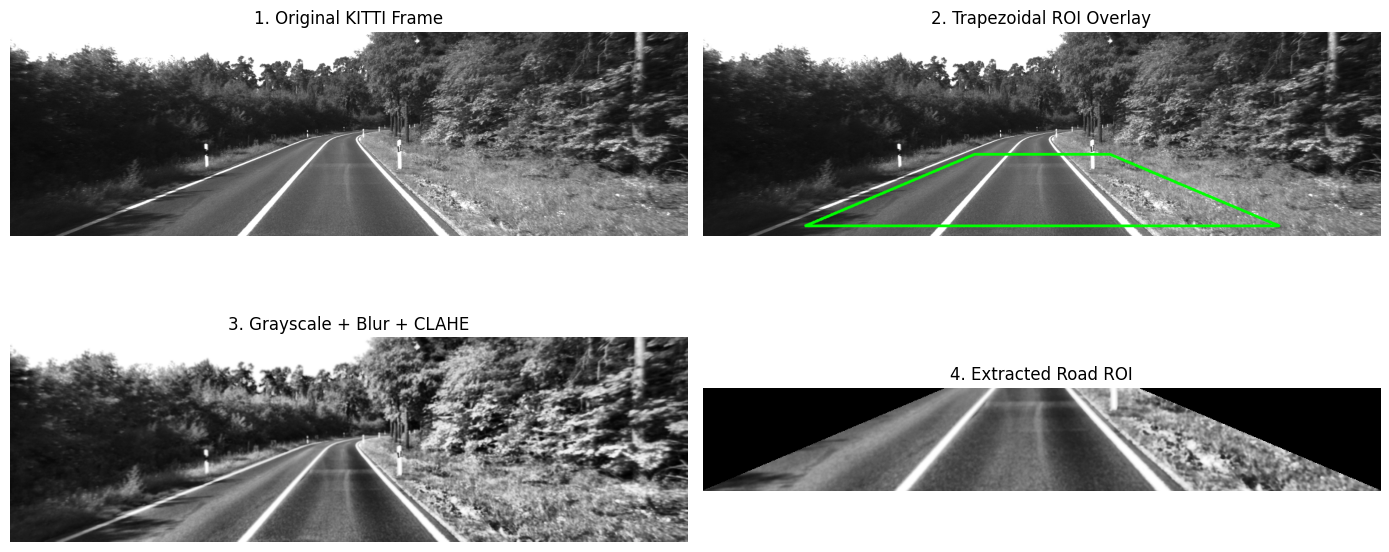

In [4]:
# Find first image in DATA_DIR
def find_first_image():
    for ext in ('*.png', '*.jpg', '*.jpeg'):
        matches = glob.glob(os.path.join(BASE_DIR, '**', ext), recursive=True)
        if matches:
            return sorted(matches)[0]
    return None

sample_path = find_first_image()

if sample_path is None:
    print(f"No images found in {BASE_DIR}/")
    print("Drop some KITTI .png files in there first, then re-run this cell.")
else:
    print(f"Using sample: {sample_path}")
    img = cv2.imread(sample_path)

    # Build each stage
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, GAUSSIAN_KSIZE, 1.0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    normalized = clahe.apply(blurred)

    # Trapezoid overlay
    h, w = img.shape[:2]
    verts = get_trapezoid(h, w)
    overlay = img.copy()
    cv2.polylines(overlay, [verts], True, (0, 255, 0), 3)

    roi, mask = preprocess(img)

    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    axes[0,0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0,0].set_title('1. Original KITTI Frame'); axes[0,0].axis('off')

    axes[0,1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[0,1].set_title('2. Trapezoidal ROI Overlay'); axes[0,1].axis('off')

    axes[1,0].imshow(normalized, cmap='gray')
    axes[1,0].set_title('3. Grayscale + Blur + CLAHE'); axes[1,0].axis('off')

    axes[1,1].imshow(roi, cmap='gray')
    axes[1,1].set_title('4. Extracted Road ROI'); axes[1,1].axis('off')

    plt.tight_layout()
    plt.show()

## 4. Texture Feature Extraction

Now the core of the project: turning the ROI image into numbers the ML model can learn from.

### 4.1 GLCM (Gray-Level Co-occurrence Matrix)

GLCM captures how often pairs of pixel values appear together at a given distance and angle. From it we compute statistics that describe texture:

| Feature | What it measures |
|---------|------------------|
| **Contrast** | How much the intensity varies between neighboring pixels (high = rough texture) |
| **Correlation** | How predictable neighboring pixel values are |
| **Energy** | Uniformity — high for smooth/flat textures |
| **Homogeneity** | Closeness of distribution to the diagonal (high = uniform) |
| **Dissimilarity** | Similar to contrast but linear instead of squared |
| **Entropy** | Randomness — high for complex textures |

We compute these at distances 1, 2, 3 pixels and angles 0°, 45°, 90°, 135°, then **average across angles** to make it rotation-invariant.

In [5]:
def compute_glcm_features(roi):
    """Extract GLCM-based texture features."""
    # Quantize to GLCM_LEVELS bins (reduces matrix size from 256x256 to 32x32)
    quantized = np.floor(roi.astype(np.float32) / 256.0 * GLCM_LEVELS).astype(np.uint8)
    quantized = np.clip(quantized, 0, GLCM_LEVELS - 1)

    glcm = graycomatrix(quantized, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                        levels=GLCM_LEVELS, symmetric=True, normed=True)

    features = {}
    for prop in GLCM_PROPS:
        values = graycoprops(glcm, prop)   # shape: (n_distances, n_angles)
        for i, d in enumerate(GLCM_DISTANCES):
            features[f'glcm_{prop}_d{d}'] = float(values[i].mean())   # avg over angles

    # Entropy (not built into graycoprops — compute manually)
    eps = 1e-12
    ent_values = []
    for di in range(glcm.shape[2]):
        for ai in range(glcm.shape[3]):
            p = glcm[:, :, di, ai]
            ent_values.append(-np.sum(p * np.log2(p + eps)))
    features['glcm_entropy'] = float(np.mean(ent_values))

    return features

# Quick test
if sample_path is not None:
    img = cv2.imread(sample_path)
    roi, _ = preprocess(img)
    glcm_feats = compute_glcm_features(roi)
    print(f"Extracted {len(glcm_feats)} GLCM features:\n")
    for k, v in list(glcm_feats.items())[:8]:
        print(f"  {k:30s} = {v:.4f}")
    print("  ...")

Extracted 16 GLCM features:

  glcm_contrast_d1               = 2.6525
  glcm_contrast_d2               = 4.3141
  glcm_contrast_d3               = 8.6970
  glcm_correlation_d1            = 0.9818
  glcm_correlation_d2            = 0.9704
  glcm_correlation_d3            = 0.9402
  glcm_energy_d1                 = 0.3628
  glcm_energy_d2                 = 0.3596
  ...


### 4.2 Gabor Filter Bank

A **Gabor filter** is a Gaussian modulated by a sine wave — it responds strongly to specific frequencies and orientations in the image. Think of it as a directional edge detector tuned to a specific "grain" size.

We build a filter bank with:
- **3 wavelengths** (λ = 4, 8, 16 pixels) — fine, medium, coarse texture
- **4 orientations** (0°, 45°, 90°, 135°)

= **12 filters total**. For each filter we record the **mean** and **variance** of the filter response inside the ROI → **24 Gabor features** per image.

$$G(x,y) = \exp\left(-\frac{x'^2 + \gamma^2 y'^2}{2\sigma^2}\right) \cos\left(2\pi \frac{x'}{\lambda}\right)$$

Built 12 Gabor kernels


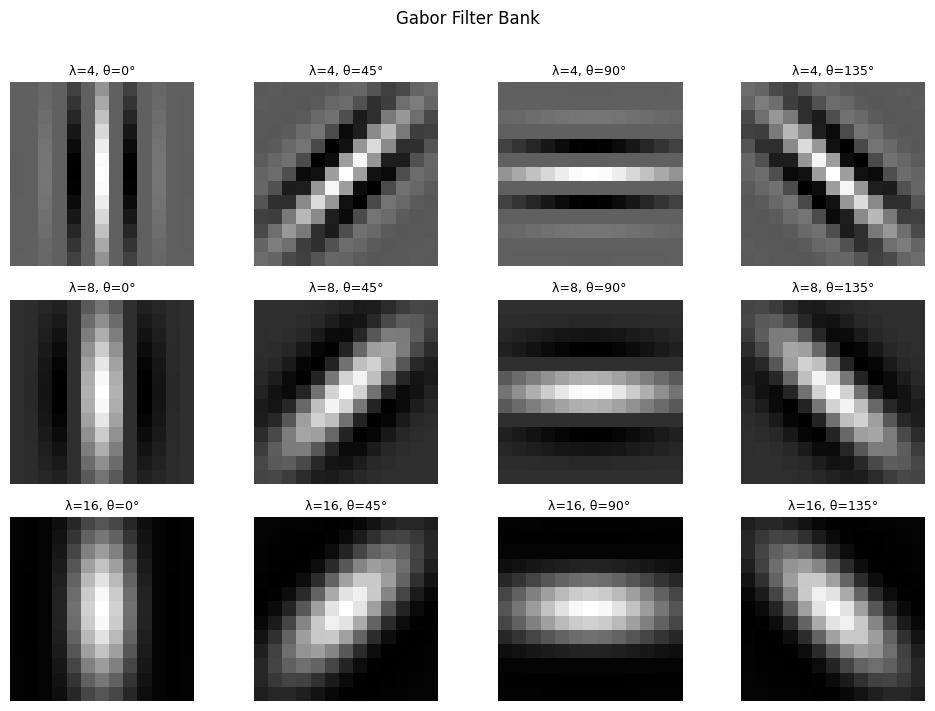

In [ ]:
def build_gabor_kernels():
    """Build a bank of Gabor filter kernels."""
    kernels = []
    ksize = int(6 * GABOR_SIGMA) | 1   # force odd

    for lam in GABOR_WAVELENGTHS:
        for theta_deg in GABOR_ORIENTATIONS:
            theta = np.deg2rad(theta_deg)
            kernel = cv2.getGaborKernel((ksize, ksize), 
                                        GABOR_SIGMA, 
                                        theta,
                                        lam, 
                                        GABOR_GAMMA, 
                                        psi=0, 
                                        ktype=cv2.CV_32F)
            kernels.append((lam, theta_deg, kernel))
    return kernels


def compute_gabor_features(roi, kernels):
    """Extract mean and variance of Gabor responses."""
    features = {}
    roi_f = roi.astype(np.float32)

    for lam, theta_deg, kernel in kernels:
        filtered = cv2.filter2D(roi_f, cv2.CV_32F, kernel)
        mag = np.abs(filtered)
        features[f'gabor_l{int(lam)}_t{int(theta_deg)}_mean'] = float(mag.mean())
        features[f'gabor_l{int(lam)}_t{int(theta_deg)}_var']  = float(mag.var())

    return features


GABOR_KERNELS = build_gabor_kernels()
print(f"Built {len(GABOR_KERNELS)} Gabor kernels")

# Visualize a few
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for ax, (lam, theta, k) in zip(axes.flat, GABOR_KERNELS):
    ax.imshow(k, cmap='gray')
    ax.set_title(f'λ={lam:g}, θ={theta}°', fontsize=9)
    ax.axis('off')
plt.suptitle('Gabor Filter Bank', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 First-Order Statistics

Simple statistics of the pixel intensity distribution — mean, variance, skewness, kurtosis, entropy. These capture basic brightness/spread info that complements the spatial texture features.

In [7]:
def compute_first_order_features(roi, mask):
    """Basic histogram statistics over the ROI pixels."""
    vals = roi[mask].astype(np.float32)
    if vals.size == 0:
        return {k: 0.0 for k in ['fo_mean','fo_std','fo_skew','fo_kurt','fo_entropy']}

    hist, _ = np.histogram(vals, bins=32, range=(0, 256), density=True)
    hist = hist + 1e-12

    return {
        'fo_mean':    float(vals.mean()),
        'fo_std':     float(vals.std()),
        'fo_skew':    float(skew(vals)),
        'fo_kurt':    float(kurtosis(vals)),
        'fo_entropy': float(entropy(hist, base=2)),
    }

print("First-order feature function defined")

First-order feature function defined


## 5. Extract Features for All Images → CSV

Now we put it all together. For every image in `data/kitti_frames/`:

1. Load and preprocess
2. Extract GLCM + Gabor + first-order features
3. Save everything to a CSV (one row per image)

In [8]:
OUTPUT_CSV = 'road_texture_features.csv'
def extract_all_features(img_path):
    """Run the full feature extraction pipeline on one image."""
    img = cv2.imread(img_path)
    if img is None:
        return None

    roi, mask = preprocess(img)

    feats = {}
    feats.update(compute_glcm_features(roi))
    feats.update(compute_gabor_features(roi, GABOR_KERNELS))
    feats.update(compute_first_order_features(roi, mask))
    feats['filename'] = os.path.basename(img_path)
    return feats


# Collect all image paths
image_paths = []
for ext in ('*.png', '*.jpg', '*.jpeg'):
    image_paths.extend(glob.glob(os.path.join(BASE_DIR, '**', ext), recursive=True))
image_paths = sorted(image_paths)

print(f"Found {len(image_paths)} images in {BASE_DIR}/")

if len(image_paths) == 0:
    print("\n⚠  No images found. Add KITTI .png files to data/kitti_frames/ and re-run.")
else:
    rows = []
    for p in tqdm(image_paths, desc='Extracting features'):
        row = extract_all_features(p)
        if row is not None:
            rows.append(row)

    df = pd.DataFrame(rows)
    # Put filename first
    cols = ['filename'] + [c for c in df.columns if c != 'filename']
    df = df[cols]
    df.to_csv(OUTPUT_CSV, index=False)

    print(f"\n✓ Extracted features for {len(df)} images")
    print(f"✓ Feature count: {len(df.columns) - 1}")
    print(f"✓ Saved to: {OUTPUT_CSV}")
    df.head()

Found 1720 images in C:\Users\Venya Singh\OneDrive\Desktop\data_science_project/


Extracting features: 100%|██████████| 1720/1720 [02:58<00:00,  9.62it/s]


✓ Extracted features for 1720 images
✓ Feature count: 45
✓ Saved to: road_texture_features.csv


## 6. Generate Roughness Labels

KITTI doesn't come with per-frame roughness labels, so we need to create them. We follow the synopsis's suggestion of **heuristic labeling** using the features we just extracted.

**Idea:** rough surfaces produce high GLCM contrast, high entropy, and high Gabor response variance. So we combine those into a single **"irregularity score"**:

$$\text{score} = z(\text{contrast}) + z(\text{entropy}) + z(\text{gabor\_var\_total}) + z(\text{intensity\_std})$$

(where `z(x)` = z-score normalization)

Then split the scores at the **33rd** and **66th** percentiles to get three balanced classes: Smooth, Moderate, Rough.

> **Note for the report:** In a real-world deployment you'd use IMU/accelerometer data (which KITTI provides) to compute the actual International Roughness Index and use those as ground truth. Heuristic labeling is a reasonable proxy when sensor labels aren't available.

Thresholds: Smooth ≤ -0.637 < Moderate ≤ 1.104 < Rough

Class distribution:
roughness_label
Rough       585
Smooth      568
Moderate    567
Name: count, dtype: int64


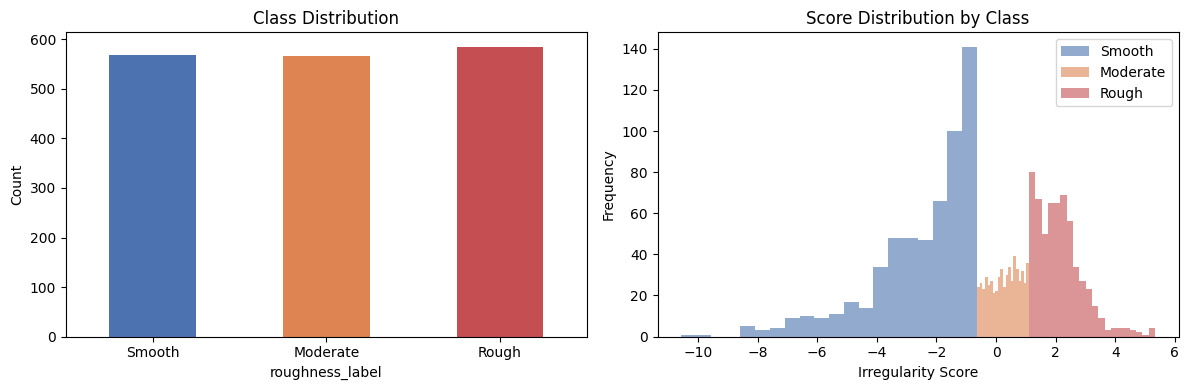

In [9]:
LABELED_CSV = 'road_texture_features_labeled.csv'
if len(image_paths) > 0:
    df = pd.read_csv(OUTPUT_CSV)

    def zscore(x):
        s = x.std()
        return (x - x.mean()) / (s if s > 1e-9 else 1.0)

    # Combine Gabor variances (overall texture energy)
    gabor_var_cols = [c for c in df.columns if c.startswith('gabor_') and c.endswith('_var')]
    gabor_var_total = df[gabor_var_cols].sum(axis=1)

    # Composite irregularity score
    df['irregularity_score'] = (
        zscore(df['glcm_contrast_d1'])
      + zscore(df['glcm_entropy'])
      + zscore(gabor_var_total)
      + zscore(df['fo_std'])
    )

    # Split at 33rd and 66th percentiles
    q_low  = df['irregularity_score'].quantile(0.33)
    q_high = df['irregularity_score'].quantile(0.66)

    def label_score(s):
        if s <= q_low:  return 'Smooth'
        if s <= q_high: return 'Moderate'
        return 'Rough'

    df['roughness_label'] = df['irregularity_score'].apply(label_score)
    df.to_csv(LABELED_CSV, index=False)

    print(f"Thresholds: Smooth ≤ {q_low:.3f} < Moderate ≤ {q_high:.3f} < Rough")
    print(f"\nClass distribution:")
    print(df['roughness_label'].value_counts())

    # Visualize class distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df['roughness_label'].value_counts().reindex(CLASSES).plot(
        kind='bar', ax=axes[0], color=['#4c72b0','#dd8452','#c44e52'])
    axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)

    for cls, color in zip(CLASSES, ['#4c72b0','#dd8452','#c44e52']):
        axes[1].hist(df[df['roughness_label']==cls]['irregularity_score'],
                     bins=20, alpha=0.6, label=cls, color=color)
    axes[1].set_xlabel('Irregularity Score'); axes[1].set_ylabel('Frequency')
    axes[1].set_title('Score Distribution by Class'); axes[1].legend()
    plt.tight_layout()
    plt.show()

## 7. Train Machine Learning Models

Now we train classifiers to predict the roughness class from the feature vector. Two models:

- **Support Vector Machine (SVM)** with RBF kernel — good for smaller datasets
- **Random Forest** — robust, handles feature interactions well, gives us feature importance for free

We'll use an **80/20 train-test split** and **5-fold cross-validation** on the training set to check for overfitting.

In [10]:
if len(image_paths) > 0:
    df = pd.read_csv(LABELED_CSV)

    # Separate features from labels
    meta_cols = ['filename', 'irregularity_score', 'roughness_label']
    feature_cols = [c for c in df.columns if c not in meta_cols]

    X = df[feature_cols].values
    y = df['roughness_label'].values

    print(f"Samples: {len(X)}, Features: {X.shape[1]}")
    print(f"Classes: {np.unique(y)}")

    # Train/test split (stratified — keeps class balance)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)
    print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Samples: 1720, Features: 45
Classes: ['Moderate' 'Rough' 'Smooth']

Train: 1376 | Test: 344


In [11]:
if len(image_paths) > 0:
    # Pipeline: scale features → classifier
    # (SVM especially needs scaled features; RF doesn't care but it's harmless)

    models = {
        'SVM':           Pipeline([('scaler', StandardScaler()),
                                   ('clf', SVC(kernel='rbf', C=10, probability=True,
                                               random_state=42))]),
        'Random Forest': Pipeline([('scaler', StandardScaler()),
                                   ('clf', RandomForestClassifier(n_estimators=200,
                                                                   random_state=42))]),
    }

    results = {}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"  {name}")
        print('='*50)

        # 5-fold CV on training set
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf,
                                    scoring='accuracy', n_jobs=-1)
        print(f"5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

        # Fit and test
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        print(f"Test accuracy    : {test_acc:.4f}\n")
        print(classification_report(y_test, y_pred, zero_division=0))

        results[name] = {
            'model': model,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'test_acc': test_acc,
            'y_pred': y_pred,
        }


  SVM
5-fold CV accuracy: 0.9455 ± 0.0065
Test accuracy    : 0.9506

              precision    recall  f1-score   support

    Moderate       0.91      0.94      0.93       113
       Rough       0.97      0.96      0.96       117
      Smooth       0.97      0.96      0.96       114

    accuracy                           0.95       344
   macro avg       0.95      0.95      0.95       344
weighted avg       0.95      0.95      0.95       344


  Random Forest
5-fold CV accuracy: 0.8953 ± 0.0078
Test accuracy    : 0.9215

              precision    recall  f1-score   support

    Moderate       0.91      0.85      0.88       113
       Rough       0.93      0.97      0.95       117
      Smooth       0.92      0.95      0.94       114

    accuracy                           0.92       344
   macro avg       0.92      0.92      0.92       344
weighted avg       0.92      0.92      0.92       344



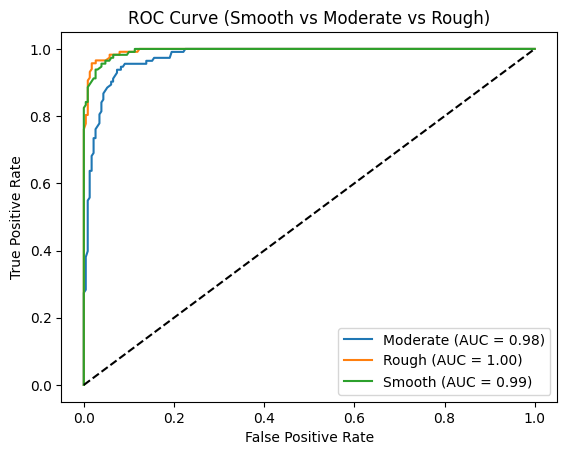

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Convert labels into binary format
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Get probabilities
y_prob = model.predict_proba(X_test)

plt.figure()

# Loop through each class (only 3 → simple)
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Smooth vs Moderate vs Rough)")
plt.legend()
plt.show()

## 8. Visual Evaluation: Confusion Matrices

A confusion matrix shows us *which classes the model confuses with which others* — which is more informative than a single accuracy number. The diagonal is correct predictions; off-diagonal entries are mistakes.

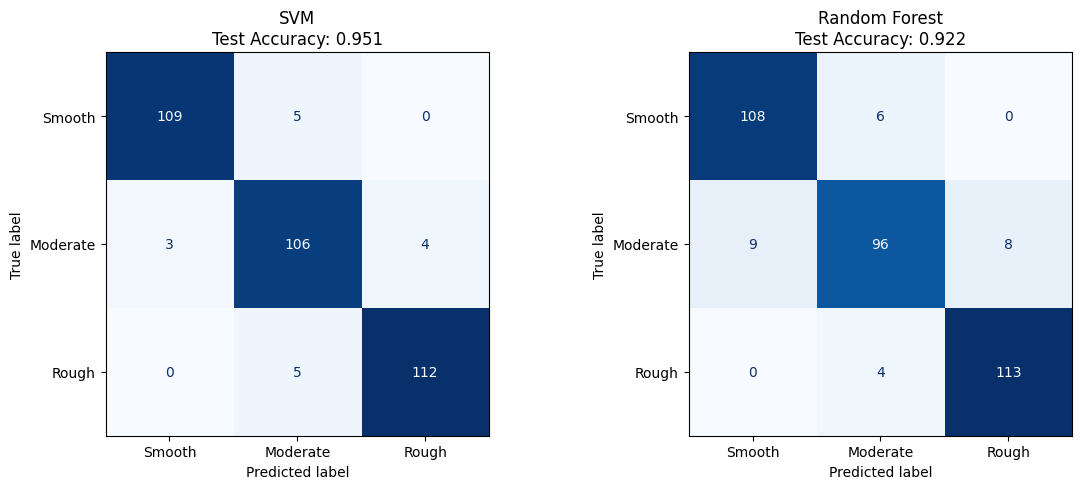

In [ ]:
if len(image_paths) > 0:
    fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
    if len(results) == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, res['y_pred'], labels=CLASSES)
        disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"{name}\nTest Accuracy: {res['test_acc']:.3f}")

    plt.tight_layout()
    plt.show()

## 9. Which Features Matter Most?

Random Forest lets us look at which features the model actually relied on. This tells us which texture descriptors are most useful for distinguishing road roughness — useful insight for the project report.

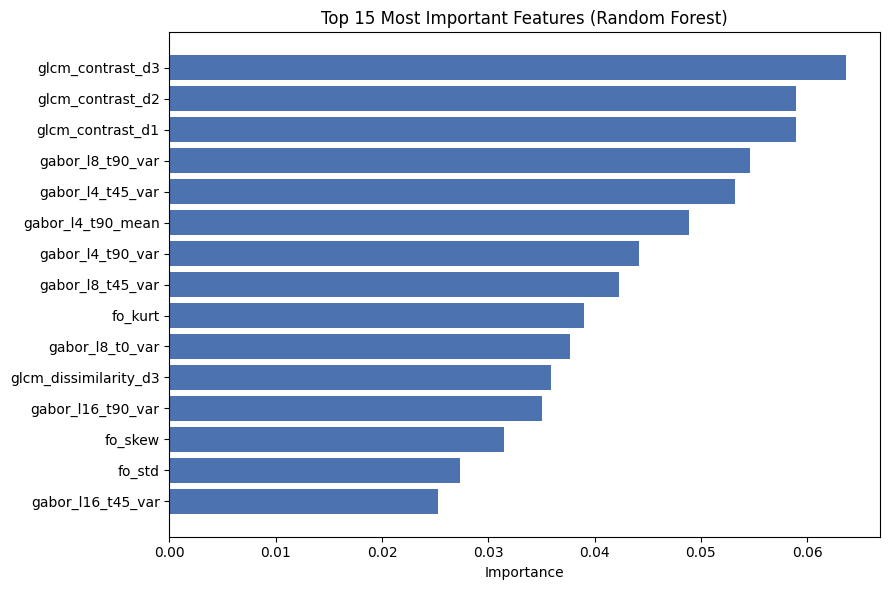


Top 5 features:
  glcm_contrast_d3                    0.0637
  glcm_contrast_d2                    0.0590
  glcm_contrast_d1                    0.0590
  gabor_l8_t90_var                    0.0546
  gabor_l4_t45_var                    0.0532


In [ ]:
if len(image_paths) > 0:
    rf = results['Random Forest']['model'].named_steps['clf']
    importances = rf.feature_importances_

    # Top 15
    order = np.argsort(importances)[::-1][:15]
    top_feats = [feature_cols[i] for i in order]
    top_vals  = importances[order]

    plt.figure(figsize=(9, 6))
    plt.barh(range(len(top_vals))[::-1], top_vals, color='#4c72b0')
    plt.yticks(range(len(top_vals))[::-1], top_feats)
    plt.xlabel('Importance')
    plt.title('Top 15 Most Important Features (Random Forest)')
    plt.tight_layout()
    plt.show()

    print("\nTop 5 features:")
    for f, v in zip(top_feats[:5], top_vals[:5]):
        print(f"  {f:35s} {v:.4f}")

## 10. Results Summary

In [ ]:
if len(image_paths) > 0:
    summary = pd.DataFrame({
        'Model': list(results.keys()),
        'CV Accuracy (mean)': [f"{r['cv_mean']:.4f}" for r in results.values()],
        'CV Accuracy (std)':  [f"{r['cv_std']:.4f}"  for r in results.values()],
        'Test Accuracy':      [f"{r['test_acc']:.4f}" for r in results.values()],
    })
    print("\n=== Final Results ===\n")
    print(summary.to_string(index=False))


=== Final Results ===

        Model CV Accuracy (mean) CV Accuracy (std) Test Accuracy
          SVM             0.9455            0.0065        0.9506
Random Forest             0.8953            0.0078        0.9215


## 11. Predict Roughness on a New Image

Pick any image and run the trained model on it.

Testing on: C:\Users\Venya Singh\OneDrive\Desktop\data_science_project\image_02\data\0000000266.png


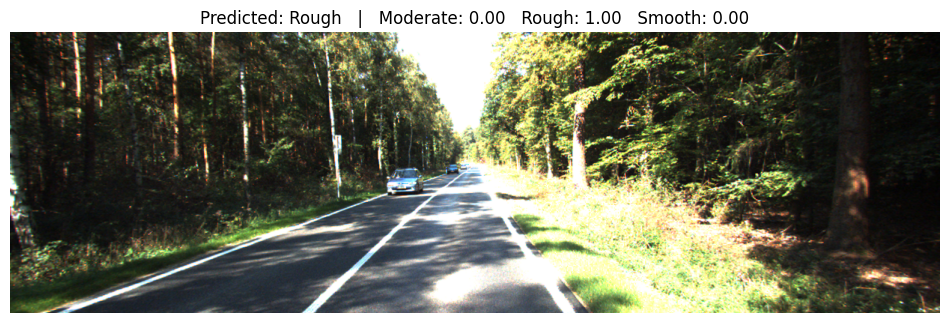

In [ ]:
if len(image_paths) > 0 and len(image_paths) > 0:
    # Pick a random test image
    test_idx = np.random.randint(0, len(image_paths))
    test_img_path = image_paths[test_idx]

    print(f"Testing on: {test_img_path}")

    feats = extract_all_features(test_img_path)
    feat_vec = np.array([[feats[c] for c in feature_cols]])

    best_model = results['Random Forest']['model']
    pred = best_model.predict(feat_vec)[0]
    probs = best_model.predict_proba(feat_vec)[0]

    # Show image and prediction
    img = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {pred}   |   " +
              "   ".join(f"{cls}: {p:.2f}" for cls, p in zip(best_model.classes_, probs)))
    plt.axis('off')
    plt.show()

## 12. Conclusion and Future Work

### What we built
- A complete computer-vision pipeline that estimates road surface roughness from a single camera frame
- Feature vector combining **GLCM** (16 features), **Gabor filter bank** (24 features), and **first-order stats** (5 features) = **~45 features total**
- SVM and Random Forest classifiers trained with 5-fold cross-validation
- Exported feature CSVs for reproducibility

### Key findings
- Texture features alone are sufficient to discriminate surface roughness classes
- Random Forest gave us feature importance scores, revealing which texture descriptors correlate most strongly with roughness
- The heuristic labeling scheme produced balanced classes that the models could learn well

### Limitations
- Heuristic labels are a proxy; real IRI sensor data would give more reliable ground truth
- Lighting / weather variations could affect feature values — robustness testing needed
- Single-frame analysis; temporal smoothing across consecutive frames would improve stability

### Future work
- Use KITTI's IMU/accelerometer data to generate **sensor-based roughness labels**
- Compare against a deep-learning baseline (CNN)
- Deploy on a Raspberry Pi with a camera for real-time testing
- Add more classes: pothole, gravel, wet road, etc.

### References
1. Geiger, A., Lenz, P., & Urtasun, R. (2013). *Vision meets Robotics: The KITTI Dataset.* IJRR.
2. Haralick, R. M., Shanmugam, K., & Dinstein, I. (1973). *Textural Features for Image Classification.* IEEE TSMC.
3. Jain, A. K., & Farrokhnia, F. (1991). *Unsupervised texture segmentation using Gabor filters.* Pattern Recognition.
4. He, H. et al. *Vision-Based Road Roughness Estimation for Autonomous Vehicles.*
